## 00. load package

In [1]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
import math
import time
import os
import pickle
from scipy import fft
import cmaps  
from typing import Optional
import sys
import matplotlib.colors as mcolors
import importlib
sys.path.append("/home/m/m301257/wave_tools")
from wave_tools.utils import dataarray_to_equatorial_latlon_grid,get_region_healpix_,create_cmap_from_string,dataarray_healpix_to_equatorial_latlon
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
import wave_tools.plotting
importlib.reload(wave_tools.spectral)
importlib.reload(wave_tools.plotting)
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)
import mpi4py
import logging
import glob

✅ 模块重新加载完成


In [2]:
# 网格转换参数

def dataarray_to_equatorial_latlon_grid(
    dataarray: xr.DataArray, grid_type: str, grid_dict: Optional[dict]
) -> xr.DataArray:
    """转换数据到赤道经纬度网格"""
    if grid_type == "latlon":
        return dataarray
    elif grid_type == "healpix":
        if grid_dict is None:
            raise ValueError("No grid_dict provided for healpix conversion.")
        return dataarray_healpix_to_equatorial_latlon(dataarray, **grid_dict)
    else:
        raise ValueError("Grid type not found.")




In [3]:
def load_or_process_data(experiment_name, dataset_key, save_path, grid_dict, target_lat, target_lon):
    """
    加载已保存的插值数据，或者处理原始数据并保存
    
    Parameters:
    -----------
    experiment_name : str
        实验名称（用于显示）
    dataset_key : str
        在catalog中的数据集键名
    save_path : str
        保存路径
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
        
    Returns:
    --------
    xr.DataArray : 插值后的数据
    """
    print("="*70)
    print(f"🔄 处理 {experiment_name} 数据...")
    print("="*70)
    
    # 检查是否已存在插值数据
    if os.path.exists(save_path):
        print(f"✅ 发现已保存的插值数据: {save_path}")
        print(f"   正在加载...")
        data_2deg = xr.open_dataarray(save_path)
        print(f"   加载完成! 形状: {data_2deg.shape}")
        return data_2deg
    
    # 如果不存在，则进行处理
    print(f"⚠️  未找到保存的数据，开始处理原始数据...")
    
    # 加载原始数据
    print(f"   1/3 加载原始数据...")
    pr_full = cat.ICON.C5[dataset_key].to_dask()['pr'].sel(time=slice("1980", "1993"))
    print(f"       原始数据形状: {pr_full.shape}")
    
    # 转换到经纬度网格
    print(f"   2/3 转换到经纬度网格...")
    pr_lon_lat = dataarray_to_equatorial_latlon_grid(pr_full, 'healpix', grid_dict)
    print(f"       转换后形状: {pr_lon_lat.shape}")
    
    # 插值到2°x2°
    print(f"   3/3 插值到2°x2°分辨率...")
    data_2deg = pr_lon_lat.interp(lat=target_lat, lon=target_lon, method='linear')
    print(f"       插值后形状: {data_2deg.shape}")
    
    # 保存数据
    print(f"   💾 保存插值数据到: {save_path}")
    data_2deg.to_netcdf(save_path)
    print(f"   ✅ 保存完成!")
    
    return data_2deg

# 设置网格参数（与之前保持一致）
grid_dict = {"nside": 256, "nest": True, "minmax_lat": 16}
target_lat = np.arange(-14, 14.1, 2.0)
target_lon = np.arange(0, 360, 2.0)

print("\n" + "="*70)
print("开始处理三个实验的数据...")
print("="*70)


开始处理三个实验的数据...


In [4]:
pwd

'/work/mh1498/m301257'

In [2]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
# 创建数据保存目录
DATA_DIR = "/work/mh1498/m301257/processed_data"
os.makedirs(DATA_DIR, exist_ok=True)
ds = (cat.ICON.C5.AMIP_CNTL.to_dask()).sel(time=slice("1980", "1993"))
ds 


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 6TB
Dimensions:             (time: 5114, cell: 786432, level_full: 26,
                         level_half: 26)
Coordinates:
  * time                (time) datetime64[ns] 41kB 1980-01-01 ... 1993-12-31
  * level_full          (level_full) float64 208B 14.0 21.0 25.0 ... 89.0 90.0
  * level_half          (level_half) float64 208B 14.0 21.0 25.0 ... 89.0 90.0
    healpix             int64 8B 1
Dimensions without coordinates: cell
Data variables: (12/47)
    clivi               (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    cllvi               (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    hus2m               (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    hfls                (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    hfss                (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    pr                  (time, cell) float32 16GB dask.array<chunksize=(128, 16384), meta=np.ndarray>
    ...                  ...
    phalf               (time, level_half, cell) float32 418GB dask.array<chunksize=(32, 4, 16384), meta=np.ndarray>
    cell_elevation      (cell) float64 6MB dask.array<chunksize=(262144,), meta=np.ndarray>
    cell_sea_land_mask  (cell) int32 3MB dask.array<chunksize=(262144,), meta=np.ndarray>
    zg                  (level_full, cell) float32 82MB dask.array<chunksize=(1, 262144), meta=np.ndarray>
    zghalf              (level_half, cell) float32 82MB dask.array<chunksize=(1, 262144), meta=np.ndarray>
    dzghalf             (level_full, cell) float32 82MB dask.array<chunksize=(1, 262144), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    Conventions:               CF-1.6
    source:                    https://gitlab.dkrz.de/icon/icon-mpim.git@6684...
    institution:               Max Planck Institute for Meteorology/Deutscher...
    title:                     ICON simulation
    references:                see MPIM/DWD publications
    comment:                   Lukas Kluft (kluftluka) on nid006406 (Linux 5....
    cdo_bitrounding_numbits:   13
    CDO:                       Climate Data Operators version 2.4.0 (https://...
    cdo_openmp_thread_number:  4
    history:                   Wed Mar 13 20:19:59 2024: ncrename -d cells,ce...
    NCO:                       netCDF Operators version 5.0.1 (Homepage = htt...

## 湿静能(MSE)加热率计算所需变量

湿静能(Moist Static Energy)定义为：**MSE = CpT + gz + Lq**

其加热率 **Q<sub>MSE</sub>** 可以表示为：

**Q<sub>MSE</sub> = Q<sub>rad</sub> + Q<sub>latent</sub> + Q<sub>sensible</sub>**

### 需要的变量：

#### 1. **辐射加热** (Q<sub>rad</sub>)
通过短波和长波辐射通量计算：
- `rsdt`, `rsut`: TOA短波辐射（向下/向上）
- `rlut`: TOA长波辐射（向上）
- `rsds`, `rsus`: 地表短波辐射（向下/向上）
- `rlds`, `rlus`: 地表长波辐射（向下/向上）

**Q<sub>rad</sub> = (SW_net + LW_net) / Δp**

#### 2. **潜热加热** (Q<sub>latent</sub>)
与降水和蒸发相关：
- `hfls`: 地表潜热通量（蒸发）
- `pr`: 降水率

**Q<sub>latent</sub> ≈ L·(E - P)** 其中 E 从 hfls 得到，P 从 pr 得到

#### 3. **感热加热** (Q<sub>sensible</sub>)
- `hfss`: 地表感热通量

#### 4. **温度和湿度剖面**（用于计算MSE）
- `ta`: 温度剖面 (3D)
- `hus`: 比湿剖面 (3D)

### 推荐处理的变量组合：

```python
# 2D变量（通量）
variables_2d = ["pr", "hfls", "hfss", 
                "rsdt", "rsut", "rlut",
                "rsds", "rsus", "rlds", "rlus"]

# 3D变量（剖面）
variables_3d = ["ta", "hus"]
```
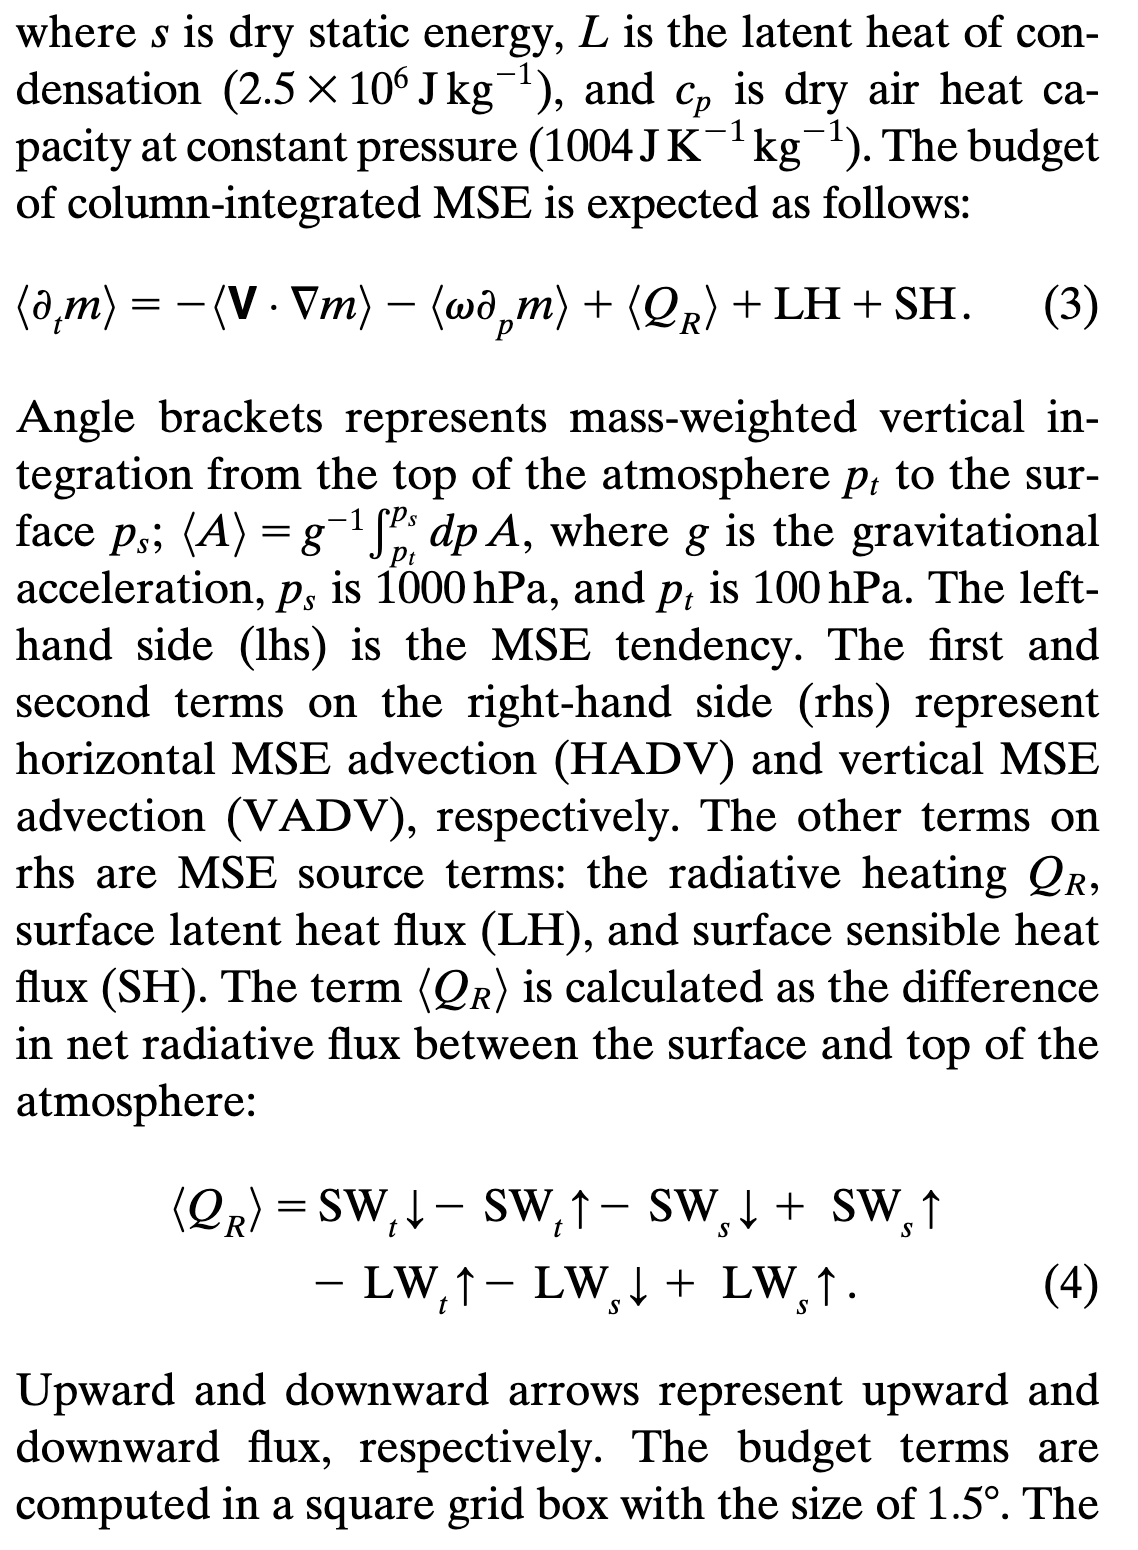

In [7]:
# 检查位势高度变量 zg
print("="*70)
print("📊 检查位势高度(Geopotential Height)变量")
print("="*70)

if 'zg' in ds:
    zg = ds['zg']
    print("\n✅ 找到位势高度变量:")
    print(f"   变量名: zg")
    print(f"   长名称: {zg.long_name if 'long_name' in zg.attrs else 'N/A'}")
    print(f"   单位: {zg.units if 'units' in zg.attrs else 'N/A'}")
    print(f"   形状: {zg.shape}")
    print(f"   维度: {list(zg.dims)}")
    print(f"   数值范围: {float(zg.min()):.1f} ~ {float(zg.max()):.1f} m")
    
    print("\n💡 重要说明:")
    print("   - zg 没有时间维度是正常的！")
    print("   - 它表示模式层的几何高度（坐标信息）")
    print("   - 对所有实验（CNTL/P4K/4CO2）都相同")
    print("   - 计算MSE时会自动广播到时间维度")
    
    print("\n⚠️  处理建议:")
    print("   1. 需要转换：healpix → 经纬度网格")
    print("   2. 需要插值：到2°x2°分辨率")
    print("   3. 只需处理一次（不用每个实验都处理）")
    print("   4. 转换后维度：(level_full, lat, lon)")
else:
    print("\n❌ 未找到 zg 变量")
    print("   检查是否有其他高度相关变量...")
    height_vars = [v for v in ds.variables if 'height' in v.lower() or 'alt' in v.lower()]
    if height_vars:
        print(f"   找到相关变量: {', '.join(height_vars)}")

print("="*70)

📊 检查位势高度(Geopotential Height)变量

✅ 找到位势高度变量:
   变量名: zg
   长名称: geometric height at full level center
   单位: m
   形状: (26, 786432)
   维度: ['level_full', 'cell']
   数值范围: -176.2 ~ 45991.2 m

💡 重要说明:
   - zg 没有时间维度是正常的！
   - 它表示模式层的几何高度（坐标信息）
   - 对所有实验（CNTL/P4K/4CO2）都相同
   - 计算MSE时会自动广播到时间维度

⚠️  处理建议:
   1. 需要转换：healpix → 经纬度网格
   2. 需要插值：到2°x2°分辨率
   3. 只需处理一次（不用每个实验都处理）
   4. 转换后维度：(level_full, lat, lon)


In [8]:
# 查找所有通量相关变量
print("="*70)
print("📊 查找所有通量(Flux)相关变量")
print("="*70)

# 定义要查找的通量变量列表
flux_variables = {
    'hfls': '潜热通量 (Surface Upward Latent Heat Flux)',
    'hfss': '感热通量 (Surface Upward Sensible Heat Flux)',
    'rsdt': '顶层向下短波辐射通量 (TOA Incident Shortwave Radiation)',
    'rsut': '顶层向上短波辐射通量 (TOA Outgoing Shortwave Radiation)',
    'rlut': '顶层向上长波辐射通量 (TOA Outgoing Longwave Radiation)',
    'rsds': '地表向下短波辐射通量 (Surface Downwelling Shortwave Radiation)',
    'rsus': '地表向上短波辐射通量 (Surface Upwelling Shortwave Radiation)',
    'rlds': '地表向下长波辐射通量 (Surface Downwelling Longwave Radiation)',
    'rlus': '地表向上长波辐射通量 (Surface Upwelling Longwave Radiation)',
}

found_vars = []
missing_vars = []

for var_name, description in flux_variables.items():
    if var_name in ds:
        var = ds[var_name]
        found_vars.append(var_name)
        print(f"\n✅ {description}")
        print(f"   变量名: {var_name}")
        print(f"   长名称: {var.long_name if 'long_name' in var.attrs else 'N/A'}")
        print(f"   单位: {var.units if 'units' in var.attrs else 'N/A'}")
        print(f"   形状: {var.shape}")
        print(f"   维度: {list(var.dims)}")
    else:
        missing_vars.append(var_name)

print("\n" + "="*70)
print(f"📊 统计:")
print(f"   找到: {len(found_vars)} 个通量变量")
print(f"   缺失: {len(missing_vars)} 个通量变量")
if missing_vars:
    print(f"   缺失列表: {', '.join(missing_vars)}")
print("="*70)

print("\n💡 提示:")
print("   - 热通量 (hfls, hfss): 地表-大气能量交换")
print("   - 辐射通量 (rs*, rl*): 短波和长波辐射")
print("   - 所有通量变量都是2D变量(time, cell)")
print("="*70)

📊 查找所有通量(Flux)相关变量

✅ 潜热通量 (Surface Upward Latent Heat Flux)
   变量名: hfls
   长名称: latent heat flux
   单位: W m-2
   形状: (5114, 786432)
   维度: ['time', 'cell']

✅ 感热通量 (Surface Upward Sensible Heat Flux)
   变量名: hfss
   长名称: sensible heat flux
   单位: W m-2
   形状: (5114, 786432)
   维度: ['time', 'cell']

✅ 顶层向下短波辐射通量 (TOA Incident Shortwave Radiation)
   变量名: rsdt
   长名称: toa incident shortwave radiation
   单位: W m-2
   形状: (5114, 786432)
   维度: ['time', 'cell']

✅ 顶层向上短波辐射通量 (TOA Outgoing Shortwave Radiation)
   变量名: rsut
   长名称: toa outgoing shortwave radiation
   单位: W m-2
   形状: (5114, 786432)
   维度: ['time', 'cell']

✅ 顶层向上长波辐射通量 (TOA Outgoing Longwave Radiation)
   变量名: rlut
   长名称: toa outgoing longwave radiation
   单位: W m-2
   形状: (5114, 786432)
   维度: ['time', 'cell']

✅ 地表向下短波辐射通量 (Surface Downwelling Shortwave Radiation)
   变量名: rsds
   长名称: surface downwelling shortwave radiation
   单位: W m-2
   形状: (5114, 786432)
   维度: ['time', 'cell']

✅ 地表向上短波辐射通量 (Surface Upwelling Shortw

In [9]:
def process_var_data(var_name, experiment_name, dataset_key, save_dir, grid_dict, target_lat, target_lon, 
                     has_level=True, level_slice=(30, None)):
    """
    处理变量数据（支持3D和2D），转换网格并插值后保存
    
    Parameters:
    -----------
    var_name : str
        变量名 ('wa', 'hus', 'ta', 'pr')
    experiment_name : str
        实验名称（用于显示）
    dataset_key : str
        在catalog中的数据集键名
    save_dir : str
        保存目录
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
    has_level : bool
        是否为3D数据（有level维度）。True=3D，False=2D
    level_slice : tuple
        level切片范围，仅当has_level=True时有效
    """
    import time
    
    data_type = "3D (多层级)" if has_level else "2D (时间序列)"
    print("="*70)
    print(f"🔄 处理 {var_name.upper()} - {experiment_name} [{data_type}]")
    print("="*70)
    
    # 创建变量和实验的子目录
    if has_level:
        exp_save_dir = os.path.join(save_dir, f"{var_name}_{experiment_name.lower()}_layers")
    else:
        exp_save_dir = os.path.join(save_dir, f"{var_name}_{experiment_name.lower()}")
    os.makedirs(exp_save_dir, exist_ok=True)
    print(f"📁 保存路径: {exp_save_dir}")
    
    # 加载数据（只读取元数据）
    print(f"📖 读取数据元信息...")
    
    if has_level:
        # 3D数据：需要选择level范围
        var_full = cat.ICON.C5[dataset_key].to_dask()[var_name].sel(
            time=slice("1980", "1993"),
            level_full=slice(*level_slice)
        )
        levels = var_full.level_full.values
        n_levels = len(levels)
        
        print(f"✅ 数据信息:")
        print(f"   变量: {var_name}")
        print(f"   时间范围: 1980-1993")
        print(f"   总层数: {n_levels}")
        print(f"   层级范围: {levels[0]:.1f} - {levels[-1]:.1f}")
        print(f"   时间步数: {len(var_full.time)}")
    else:
        # 2D数据：只有时间维度
        var_full = cat.ICON.C5[dataset_key].to_dask()[var_name].sel(
            time=slice("1980", "1993")
        )
        
        print(f"✅ 数据信息:")
        print(f"   变量: {var_name}")
        print(f"   时间范围: 1980-1993")
        print(f"   时间步数: {len(var_full.time)}")
    
    print("="*70)
    
    # 逐层处理（3D）或整体处理（2D）
    total_start_time = time.time()
    
    if has_level:
        # ========== 3D数据：逐层处理 ==========
        for idx, level in enumerate(levels, 1):
            layer_start_time = time.time()
            
            # 构建保存路径
            save_path = os.path.join(exp_save_dir, f"{var_name}_lev_{int(level):03d}.nc")
            
            # 检查是否已处理
            if os.path.exists(save_path):
                print(f"✅ [{idx}/{n_levels}] Level {int(level):3d} - 已存在，跳过")
                continue
            
            print(f"🔄 [{idx}/{n_levels}] 处理 Level {int(level):3d}...")
            
            try:
                # 1. 选择单层数据
                var_layer = var_full.sel(level_full=level)
                print(f"   ├─ 选择层级完成")
                
                # 2. 转换到经纬度网格
                var_lonlat = dataarray_to_equatorial_latlon_grid(var_layer, 'healpix', grid_dict)
                print(f"   ├─ 网格转换完成: {var_lonlat.shape}")
                
                # 3. 插值到2°x2°
                var_2deg = var_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
                print(f"   ├─ 插值完成: {var_2deg.shape}")
                
                # 4. 转换为Dataset并设置变量名，然后保存
                ds_to_save = var_2deg.to_dataset(name=var_name)
                ds_to_save.to_netcdf(save_path)
                
                # 计算时间
                layer_time = time.time() - layer_start_time
                elapsed_time = time.time() - total_start_time
                avg_time_per_layer = elapsed_time / idx
                remaining_layers = n_levels - idx
                estimated_remaining = avg_time_per_layer * remaining_layers
                
                print(f"   ✅ 保存完成: {os.path.basename(save_path)}")
                print(f"   ⏱️  本层耗时: {layer_time:.1f}s | 平均: {avg_time_per_layer:.1f}s/层")
                print(f"   📊 预计剩余时间: {estimated_remaining/60:.1f} 分钟")
                print()
                
            except Exception as e:
                print(f"   ❌ 处理失败: {str(e)}")
                continue
    
    else:
        # ========== 2D数据：整体处理 ==========
        save_path = os.path.join(exp_save_dir, f"{var_name}_2deg_interp.nc")
        
        # 检查是否已处理
        if os.path.exists(save_path):
            print(f"✅ 数据已存在，跳过处理")
            print(f"   文件: {save_path}")
        else:
            print(f"🔄 开始处理2D数据...")
            
            try:
                # 1. 转换到经纬度网格
                print(f"   ├─ 网格转换中...")
                var_lonlat = dataarray_to_equatorial_latlon_grid(var_full, 'healpix', grid_dict)
                print(f"   ├─ 网格转换完成: {var_lonlat.shape}")
                
                # 2. 插值到2°x2°
                print(f"   ├─ 插值中...")
                var_2deg = var_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
                print(f"   ├─ 插值完成: {var_2deg.shape}")
                
                # 3. 转换为Dataset并设置变量名，然后保存
                print(f"   ├─ 保存中...")
                ds_to_save = var_2deg.to_dataset(name=var_name)
                ds_to_save.to_netcdf(save_path)
                
                total_time = time.time() - total_start_time
                print(f"   ✅ 保存完成: {os.path.basename(save_path)}")
                print(f"   ⏱️  总耗时: {total_time/60:.1f} 分钟")
                
            except Exception as e:
                print(f"   ❌ 处理失败: {str(e)}")
    
    total_time = time.time() - total_start_time
    print("="*70)
    print(f"✅ {var_name.upper()} - {experiment_name} 处理完成!")
    print(f"   总耗时: {total_time/60:.1f} 分钟")
    print(f"   保存目录: {exp_save_dir}")
    print("="*70)
    print()


## 循环转换数据-气压层

In [10]:
# 设置保存目录
LAYER_DIR = os.path.join(DATA_DIR, "3d_layers")
os.makedirs(LAYER_DIR, exist_ok=True)

# 网格参数
grid_dict = {"nside": 256, "nest": True, "minmax_lat": 16}
target_lat = np.arange(-14, 14.1, 2.0)
target_lon = np.arange(0, 360, 2.0)

# 要处理的变量列表（3D和2D）
variables_3d = ["ua"]  # 3D变量：需要逐层处理
# variables_2d = [ "hfls", "hfss", 
#                 "rsdt", "rsut", "rlut",
#                 "rsds", "rsus", "rlds", "rlus"]
          

print("="*70)
print("🚀 开始处理所有变量")
print("="*70)
print(f"3D变量: {len(variables_3d)} ({', '.join(variables_3d)})")
# print(f"2D变量: {len(variables_2d)} ({', '.join(variables_2d)})")
print(f"实验数量: 3 (CNTL, P4K, 4CO2)")
print(f"目标分辨率: 2° x 2°")
print(f"纬度范围: -14° to 14°")
print("="*70)
print()

# 图片保存路径
fig_save_path = os.path.join("/home/m/m301257/", "fig") 
os.makedirs(fig_save_path, exist_ok=True)

print("="*70)
print("📁 数据保存路径设置完成")
print("="*70)
print(f"3D数据目录: {LAYER_DIR}")
print(f"图片目录: {fig_save_path}")
print("="*70)
print()

# 定义实验配置
experiments = {
    "cntl":  ("CNTL",   "AMIP_CNTL"),
    "4k":    ("P4K",    "AMIP_P4K"),
    "4co2":  ("4CO2",   "AMIP_4CO2"),
}

# 处理所有变量和实验
all_start_time = time.time()

# 处理3D变量
for var_name in variables_3d:
    print("\n" + "="*70)
    print(f"📊 开始处理3D变量: {var_name.upper()}")
    print("="*70 + "\n")
    
    for exp_key, (exp_name, dataset_key) in experiments.items():
        try:
            process_var_data(
                var_name=var_name,
                experiment_name=exp_name,
                dataset_key=dataset_key,
                save_dir=LAYER_DIR,
                grid_dict=grid_dict,
                target_lat=target_lat,
                target_lon=target_lon,
                has_level=True  # 3D数据
            )
        except Exception as e:
            print(f"❌ {var_name.upper()} - {exp_name} 处理失败: {str(e)}")
            print()
            continue

# 处理2D变量
# for var_name in variables_2d:
#     print("\n" + "="*70)
#     print(f"📊 开始处理2D变量: {var_name.upper()}")
#     print("="*70 + "\n")
    
#     for exp_key, (exp_name, dataset_key) in experiments.items():
#         try:
#             process_var_data(
#                 var_name=var_name,
#                 experiment_name=exp_name,
#                 dataset_key=dataset_key,
#                 save_dir=LAYER_DIR,
#                 grid_dict=grid_dict,
#                 target_lat=target_lat,
#                 target_lon=target_lon,
#                 has_level=False  # 2D数据
#             )
#         except Exception as e:
#             print(f"❌ {var_name.upper()} - {exp_name} 处理失败: {str(e)}")
#             print()
#             continue

all_total_time = time.time() - all_start_time
print("\n" + "="*70)
print("🎉 所有变量和实验处理完成!")
print(f"3D变量数: {len(variables_3d)}")
# print(f"2D变量数: {len(variables_2d)}")
print(f"实验数: {len(experiments)}")
print(f"总耗时: {all_total_time/60:.1f} 分钟 ({all_total_time/3600:.2f} 小时)")
print("="*70)

🚀 开始处理所有变量
3D变量: 1 (ua)
实验数量: 3 (CNTL, P4K, 4CO2)
目标分辨率: 2° x 2°
纬度范围: -14° to 14°

📁 数据保存路径设置完成
3D数据目录: /work/mh1498/m301257/processed_data/3d_layers
图片目录: /home/m/m301257/fig


📊 开始处理3D变量: UA

🔄 处理 UA - CNTL [3D (多层级)]
📁 保存路径: /work/mh1498/m301257/processed_data/3d_layers/ua_cntl_layers
📖 读取数据元信息...
❌ UA - CNTL 处理失败: "'level_full' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 6756, 'level_half': 26, 'cell': 786432})"

🔄 处理 UA - P4K [3D (多层级)]
📁 保存路径: /work/mh1498/m301257/processed_data/3d_layers/ua_p4k_layers
📖 读取数据元信息...


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


❌ UA - P4K 处理失败: "'level_full' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 5478, 'level_half': 26, 'cell': 786432})"

🔄 处理 UA - 4CO2 [3D (多层级)]
📁 保存路径: /work/mh1498/m301257/processed_data/3d_layers/ua_4co2_layers
📖 读取数据元信息...
❌ UA - 4CO2 处理失败: "'level_full' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 5479, 'level_half': 26, 'cell': 786432})"


🎉 所有变量和实验处理完成!
3D变量数: 1
实验数: 3
总耗时: 0.1 分钟 (0.00 小时)


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


## 合并变量，修改变量名称，合并数据

In [11]:
def change_variable_name_and_merge_per_folder(in_paths, base_out_path, pattern,
                                              old_var_name, new_var_name,
                                              merged_file_name="wa_all_levels.nc",
                                              skip_existing=True,
                                              has_level=True):
    """
    批量更改NetCDF文件中的变量名，添加level维度（如果需要），并在每个子文件夹生成合并文件
    同时保留输入子文件夹结构
    
    Parameters:
    -----------
    skip_existing : bool
        如果为True，跳过已存在的单个文件和合并文件（默认True）
    has_level : bool
        如果为True，处理3D数据（从文件名提取level维度）
        如果为False，处理2D数据（直接合并，不添加level维度）
    """
    import os
    import glob
    import xarray as xr

    for in_path in in_paths:
        # 当前输入文件夹名称
        folder_name = os.path.basename(os.path.normpath(in_path))
        out_path = os.path.join(base_out_path, folder_name)
        os.makedirs(out_path, exist_ok=True)
        
        # 检查合并文件是否已存在
        merged_file = os.path.join(out_path, merged_file_name)
        if skip_existing and os.path.exists(merged_file):
            print(f"✅ {folder_name}: 合并文件已存在，跳过处理")
            print(f"   文件: {merged_file}")
            continue

        file_pattern = os.path.join(in_path, pattern)
        input_files = sorted(glob.glob(file_pattern))
        
        if not input_files:
            print(f"⚠️ 文件夹 {folder_name} 没有匹配的文件 (pattern: {pattern})")
            continue
        
        data_type = "3D (多层级)" if has_level else "2D (单层/时间序列)"
        print(f"\n{'='*70}")
        print(f"🔄 处理文件夹: {folder_name} [{data_type}]")
        print(f"   输入路径: {in_path}")
        print(f"   输出路径: {out_path}")
        print(f"   找到文件数: {len(input_files)}")
        print(f"{'='*70}")
        
        datasets = []
        processed_count = 0
        skipped_count = 0

        for file in input_files:
            filename = os.path.basename(file)
            new_file = os.path.join(out_path, filename)

            # 检查单个文件是否已存在
            if skip_existing and os.path.exists(new_file):
                skipped_count += 1
                # 仍需加载用于合并
                try:
                    with xr.open_dataset(new_file) as ds:
                        if has_level:
                            # 3D数据：需要level维度
                            level = int(filename.split("_")[2].replace(".nc", ""))
                            ds = ds.expand_dims({"level": [level]}) if "level" not in ds.dims else ds
                        datasets.append(ds)
                except Exception as e:
                    print(f"⚠️ 跳过的文件加载失败: {filename} - {str(e)}")
                continue

            # 处理新文件
            try:
                if has_level:
                    # 3D数据：从文件名提取 level (例如: hus_lev_031.nc -> 31)
                    try:
                        level = int(filename.split("_")[2].replace(".nc", ""))
                    except:
                        print(f"⚠️ 无法从文件名提取 level: {filename}, 跳过")
                        continue
                
                with xr.open_dataset(file) as ds:
                    # 修改变量名（如果需要）
                    if old_var_name in ds and old_var_name != new_var_name:
                        ds = ds.rename({old_var_name: new_var_name})
                    
                    # 3D数据需要添加 level 维度
                    if has_level:
                        ds = ds.expand_dims({"level": [level]})
                    
                    # 保存到新路径
                    ds.to_netcdf(new_file, mode="w")
                    processed_count += 1
                    
                    if processed_count % 5 == 0 or processed_count == len(input_files):
                        print(f"✅ [{processed_count}/{len(input_files)}] 已处理: {filename}")
                    
                    datasets.append(ds)
            except Exception as e:
                print(f"❌ 处理失败: {filename} - {str(e)}")
                continue

        # 统计信息
        print(f"\n📊 处理统计:")
        print(f"   新处理: {processed_count} 个文件")
        print(f"   已跳过: {skipped_count} 个文件")
        print(f"   总计: {len(datasets)} 个文件用于合并")

        # 每个子文件夹单独合并
        if datasets:
            try:
                if has_level:
                    # 3D数据：沿level维度合并
                    ds_all = xr.concat(datasets, dim="level")
                else:
                    # 2D数据：直接合并（沿时间或其他维度）
                    ds_all = xr.concat(datasets, dim="time") if "time" in datasets[0].dims else xr.merge(datasets)
                
                var_data = ds_all[new_var_name]
                var_data.to_netcdf(merged_file)
                print(f"🎉 {folder_name} 合并完成!")
                print(f"   保存到: {merged_file}")
                print(f"   形状: {var_data.shape}")
                print(f"   维度: {list(var_data.dims)}")
            except Exception as e:
                print(f"❌ 合并失败: {str(e)}")
        else:
            print(f"⚠️ 文件夹 {folder_name} 没有可处理的文件！")


## merge_files

In [12]:
input_folders1 = [
    "/work/mh1498/m301257/processed_data/3d_layers/hus_4co2_layers",
    "/work/mh1498/m301257/processed_data/3d_layers/hus_cntl_layers",
    "/work/mh1498/m301257/processed_data/3d_layers/hus_p4k_layers",
    
]

input_folders2 = [
    "/work/mh1498/m301257/processed_data/3d_layers/ta_4co2_layers",
    "/work/mh1498/m301257/processed_data/3d_layers/ta_cntl_layers",
    "/work/mh1498/m301257/processed_data/3d_layers/ta_p4k_layers"    
]

base_output_folder = "/work/mh1498/m301257"

# # 处理3D数据 (hus - 比湿)
# change_variable_name_and_merge_per_folder(
#     in_paths=input_folders1,
#     base_out_path=base_output_folder,
#     pattern="hus_lev_*.nc",
#     old_var_name="hus",
#     new_var_name="hus",
#     has_level=True  # 3D数据，有level维度
# )

# # 处理3D数据 (ta - 温度)
# change_variable_name_and_merge_per_folder(
#     in_paths=input_folders2,
#     base_out_path=base_output_folder,
#     pattern="ta_lev_*.nc",
#     old_var_name="ta",
#     new_var_name="ta",
#     has_level=True  # 3D数据，有level维度
# )

## 步骤1: 处理位势高度(zg)数据

In [13]:
# 备选方案：如果上面的方法仍然崩溃，使用这个分批保存版本
def process_zg_data_batch(dataset_key, save_path, grid_dict, target_lat, target_lon, batch_size=5):
    """
    处理位势高度数据 - 分批保存版本（更节省内存）
    """
    import time
    import tempfile
    
    print("="*70)
    print("🔄 处理位势高度(zg)数据 - 分批保存版本")
    print("="*70)
    
    if os.path.exists(save_path):
        print(f"✅ 发现已保存的zg数据: {save_path}")
        zg_2deg = xr.open_dataarray(save_path)
        print(f"   加载完成! 形状: {zg_2deg.shape}")
        return zg_2deg
    
    print("⚠️  未找到保存的数据，开始处理...")
    
    # 创建临时目录
    temp_dir = os.path.join(DATA_DIR, "temp_zg")
    os.makedirs(temp_dir, exist_ok=True)
    
    # 1. 加载zg数据
    print("   1/4 加载zg数据...")
    zg_full = cat.ICON.C5[dataset_key].to_dask()['zg']
    zg_selected = zg_full.sel(level_full=slice(30, None))
    levels = zg_selected.level_full.values
    n_levels = len(levels)
    print(f"       需要处理的层数: {n_levels}")
    print(f"       批次大小: {batch_size} 层/批")
    
    # 2. 分批处理
    print("   2/4 分批处理...")
    start_time = time.time()
    temp_files = []
    
    for batch_start in range(0, n_levels, batch_size):
        batch_end = min(batch_start + batch_size, n_levels)
        batch_levels = levels[batch_start:batch_end]
        
        print(f"       处理批次 {batch_start//batch_size + 1}: levels {int(batch_levels[0])}-{int(batch_levels[-1])}")
        
        batch_data = []
        for level in batch_levels:
            zg_layer = zg_selected.sel(level_full=level).compute()
            zg_layer_with_time = zg_layer.expand_dims({'time': [0]})
            zg_lonlat_with_time = dataarray_to_equatorial_latlon_grid(
                zg_layer_with_time, 'healpix', grid_dict
            )
            zg_lonlat = zg_lonlat_with_time.squeeze('time', drop=True)
            zg_2deg_layer = zg_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
            zg_2deg_layer = zg_2deg_layer.expand_dims({'level_full': [level]})
            batch_data.append(zg_2deg_layer.values)
        
        # 保存批次
        batch_values = np.concatenate(batch_data, axis=0)
        batch_file = os.path.join(temp_dir, f"batch_{batch_start:03d}.npy")
        np.save(batch_file, batch_values)
        temp_files.append((batch_file, batch_levels))
        print(f"          ✅ 批次已保存")
    
    # 3. 合并所有批次
    print("   3/4 合并所有批次...")
    all_values = []
    for temp_file, _ in temp_files:
        all_values.append(np.load(temp_file))
    zg_values = np.concatenate(all_values, axis=0)
    
    # 4. 创建最终DataArray并保存
    print("   4/4 创建并保存最终文件...")
    zg_2deg = xr.DataArray(
        zg_values,
        dims=['level_full', 'lat', 'lon'],
        coords={'level_full': levels, 'lat': target_lat, 'lon': target_lon},
        name='zg'
    )
    ds_to_save = zg_2deg.to_dataset(name='zg')
    ds_to_save.to_netcdf(save_path)
    
    # 清理临时文件
    import shutil
    shutil.rmtree(temp_dir)
    
    total_time = time.time() - start_time
    print(f"   ⏱️  总耗时: {total_time/60:.1f} 分钟")
    print("="*70)
    return zg_2deg

# 如果上面的方法崩溃，取消下面的注释使用这个版本
# zg_2deg = process_zg_data_batch(
#     dataset_key="AMIP_CNTL",
#     save_path=ZG_SAVE_PATH,
#     grid_dict=grid_dict,
#     target_lat=target_lat,
#     target_lon=target_lon,
#     batch_size=5  # 每次处理5层
# )

In [14]:
def process_zg_data(dataset_key, save_path, grid_dict, target_lat, target_lon):
    """
    处理位势高度数据（只需处理一次，所有实验共用）
    逐层处理，因为转换函数不支持3D数据
    
    Parameters:
    -----------
    dataset_key : str
        任意一个实验的数据集键名（zg对所有实验相同）
    save_path : str
        保存路径
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
    
    Returns:
    --------
    xr.DataArray : 处理后的zg数据 (level_full, lat, lon)
    """
    import time
    
    print("="*70)
    print("🔄 处理位势高度(zg)数据 - 逐层处理")
    print("="*70)
    
    # 检查是否已存在
    if os.path.exists(save_path):
        print(f"✅ 发现已保存的zg数据: {save_path}")
        zg_2deg = xr.open_dataarray(save_path)
        print(f"   加载完成! 形状: {zg_2deg.shape}")
        return zg_2deg
    
    print("⚠️  未找到保存的数据，开始处理...")
    
    # 1. 加载zg数据
    print("   1/3 加载zg数据...")
    zg_full = cat.ICON.C5[dataset_key].to_dask()['zg']
    print(f"       原始形状: {zg_full.shape}")
    print(f"       维度: {list(zg_full.dims)}")
    
    # 2. 选择level范围（与ta, hus保持一致）
    zg_selected = zg_full.sel(level_full=slice(30, None))
    levels = zg_selected.level_full.values
    n_levels = len(levels)
    print(f"       选择level>=30后形状: {zg_selected.shape}")
    print(f"       需要处理的层数: {n_levels}")
    
    # 3. 逐层处理并立即插值（避免内存累积）
    print("   2/3 逐层转换到经纬度网格并插值...")
    zg_layers_interpolated = []
    start_time = time.time()
    
    for idx, level in enumerate(levels, 1):
        # 选择单层并立即计算（不保留为dask）
        zg_layer = zg_selected.sel(level_full=level).compute()
        
        # 添加临时time维度
        zg_layer_with_time = zg_layer.expand_dims({'time': [0]})
        
        # 转换到经纬度网格
        zg_lonlat_with_time = dataarray_to_equatorial_latlon_grid(
            zg_layer_with_time, 'healpix', grid_dict
        )
        
        # 移除time维度
        zg_lonlat = zg_lonlat_with_time.squeeze('time', drop=True)
        
        # 立即插值到2°x2°（减少数据量）
        zg_2deg_layer = zg_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
        
        # 添加level维度
        zg_2deg_layer = zg_2deg_layer.expand_dims({'level_full': [level]})
        
        # 转换为numpy以节省内存
        zg_layers_interpolated.append(zg_2deg_layer.values)
        
        # 进度显示
        if idx % 5 == 0 or idx == n_levels:
            elapsed = time.time() - start_time
            avg_time = elapsed / idx
            remaining = avg_time * (n_levels - idx)
            print(f"       进度: [{idx}/{n_levels}] 已用时: {elapsed:.1f}s, 预计剩余: {remaining:.1f}s")
    
    # 4. 构建最终的DataArray
    print("   3/3 组装最终数据...")
    # 合并numpy数组
    zg_values = np.concatenate(zg_layers_interpolated, axis=0)
    
    # 创建DataArray
    zg_2deg = xr.DataArray(
        zg_values,
        dims=['level_full', 'lat', 'lon'],
        coords={
            'level_full': levels,
            'lat': target_lat,
            'lon': target_lon
        },
        name='zg'
    )
    print(f"       最终形状: {zg_2deg.shape}")
    
    # 6. 保存
    print(f"   💾 保存到: {save_path}")
    ds_to_save = zg_2deg.to_dataset(name='zg')
    ds_to_save.to_netcdf(save_path)
    print("   ✅ 保存完成!")
    
    total_time = time.time() - start_time
    print(f"   ⏱️  总耗时: {total_time/60:.1f} 分钟")
    print("="*70)
    return zg_2deg

# 处理zg（只需处理一次）
ZG_SAVE_PATH = os.path.join(DATA_DIR, "zg_2deg_interp.nc")

zg_2deg = process_zg_data(
    dataset_key="AMIP_CNTL",  # 任意选一个实验即可
    save_path=ZG_SAVE_PATH,
    grid_dict=grid_dict,
    target_lat=target_lat,
    target_lon=target_lon
)

🔄 处理位势高度(zg)数据 - 逐层处理
✅ 发现已保存的zg数据: /work/mh1498/m301257/processed_data/zg_2deg_interp.nc
   加载完成! 形状: (22, 15, 180)


## 步骤2: 计算湿静能(MSE)

In [ ]:
def calculate_mse(ta_path, hus_path, zg_2deg, output_path):
    """
    计算湿静能 MSE = Cp*T + g*z + L*q
    
    Parameters:
    -----------
    ta_path : str
        温度数据路径（合并后的文件）
    hus_path : str
        比湿数据路径（合并后的文件）
    zg_2deg : xr.DataArray
        位势高度数据 (level_full, lat, lon)
    output_path : str
        MSE输出路径
        
    Returns:
    --------
    xr.DataArray : MSE数据 (time, level, lat, lon)
    """
    import numpy as np
    
    print("="*70)
    print(f"🔄 计算MSE: {os.path.basename(output_path)}")
    print("="*70)
    
    # 检查是否已存在
    if os.path.exists(output_path):
        print(f"✅ MSE文件已存在: {output_path}")
        mse = xr.open_dataarray(output_path)
        print(f"   形状: {mse.shape}")
        return mse
    
    # 物理常数
    Cp = 1004.0      # J/(kg·K) - 定压比热
    g = 9.81         # m/s² - 重力加速度  
    L = 2.5e6        # J/kg - 蒸发潜热
    
    print("📖 加载数据...")
    # 加载ta和hus（合并后的文件）
    ta = xr.open_dataarray(ta_path)
    hus = xr.open_dataarray(hus_path)
    
    print(f"   ta形状: {ta.shape}")
    print(f"   hus形状: {hus.shape}")
    print(f"   zg形状: {zg_2deg.shape}")
    
    print("🧮 计算MSE各分量...")
    # 计算各分量
    sensible = Cp * ta              # 显热 (time, level, lat, lon)
    potential = g * zg_2deg         # 位势能 (level, lat, lon) → 自动广播
    latent = L * hus                # 潜热 (time, level, lat, lon)
    
    print("   ├─ 显热项: Cp*T")
    print("   ├─ 位势能项: g*z")  
    print("   └─ 潜热项: L*q")
    
    # 总MSE
    mse = sensible + potential + latent
    mse.name = 'mse'
    mse.attrs['long_name'] = 'Moist Static Energy'
    mse.attrs['units'] = 'J/kg'
    mse.attrs['description'] = 'MSE = Cp*T + g*z + L*q'
    
    print(f"✅ MSE计算完成! 形状: {mse.shape}")
    
    # 保存
    print(f"💾 保存到: {output_path}")
    mse.to_netcdf(output_path)
    print("="*70)
    
    return mse

# 为三个实验计算MSE
print("\n" + "="*70)
print("🚀 开始计算所有实验的MSE")
print("="*70 + "\n")

experiments_mse = {
    "CNTL": {
        "ta": "/work/mh1498/m301257/ta_cntl_layers/ta_all_levels.nc",
        "hus": "/work/mh1498/m301257/hus_cntl_layers/hus_all_levels.nc",
        "mse_out": os.path.join(DATA_DIR, "mse_cntl.nc")
    },
    "P4K": {
        "ta": "/work/mh1498/m301257/ta_p4k_layers/ta_all_levels.nc",
        "hus": "/work/mh1498/m301257/hus_p4k_layers/hus_all_levels.nc",
        "mse_out": os.path.join(DATA_DIR, "mse_p4k.nc")
    },
    "4CO2": {
        "ta": "/work/mh1498/m301257/ta_4co2_layers/ta_all_levels.nc",
        "hus": "/work/mh1498/m301257/hus_4co2_layers/hus_all_levels.nc",
        "mse_out": os.path.join(DATA_DIR, "mse_4co2.nc")
    }
}

mse_data = {}
for exp_name, paths in experiments_mse.items():
    try:
        mse_data[exp_name] = calculate_mse(
            ta_path=paths["ta"],
            hus_path=paths["hus"],
            zg_2deg=zg_2deg,
            output_path=paths["mse_out"]
        )
    except Exception as e:
        print(f"❌ {exp_name} MSE计算失败: {str(e)}")
        continue

print("\n✅ 所有实验MSE计算完成!")


🚀 开始计算所有实验的MSE

🔄 计算MSE: mse_cntl.nc
📖 加载数据...
   ta形状: (22, 5114, 15, 180)
   hus形状: (22, 5114, 15, 180)
   zg形状: (22, 15, 180)
🧮 计算MSE各分量...
   ├─ 显热项: Cp*T
   ├─ 位势能项: g*z
   └─ 潜热项: L*q


## 步骤3: 分析热通量差异

分析潜热通量(hfls)和感热通量(hfss)在三个实验间的差异，以理解是否通量差异导致了EOF垂直结构的差异。

In [ ]:
# 加载三个实验的热通量数据
print("="*70)
print("📊 加载热通量数据")
print("="*70)

flux_paths = {
    "CNTL": {
        "hfls": os.path.join(LAYER_DIR, "hfls_cntl/hfls_2deg_interp.nc"),
        "hfss": os.path.join(LAYER_DIR, "hfss_cntl/hfss_2deg_interp.nc")
    },
    "P4K": {
        "hfls": os.path.join(LAYER_DIR, "hfls_p4k/hfls_2deg_interp.nc"),
        "hfss": os.path.join(LAYER_DIR, "hfss_p4k/hfss_2deg_interp.nc")
    },
    "4CO2": {
        "hfls": os.path.join(LAYER_DIR, "hfls_4co2/hfls_2deg_interp.nc"),
        "hfss": os.path.join(LAYER_DIR, "hfss_4co2/hfss_2deg_interp.nc")
    }
}

# 加载数据
hfls_data = {}
hfss_data = {}

for exp_name, paths in flux_paths.items():
    print(f"\n🔄 加载 {exp_name}...")
    try:
        hfls_data[exp_name] = xr.open_dataarray(paths["hfls"])
        hfss_data[exp_name] = xr.open_dataarray(paths["hfss"])
        print(f"   ✅ hfls形状: {hfls_data[exp_name].shape}")
        print(f"   ✅ hfss形状: {hfss_data[exp_name].shape}")
    except Exception as e:
        print(f"   ❌ 加载失败: {str(e)}")
        print(f"   请确认已运行数据处理cell生成这些文件")

print("\n" + "="*70)

In [ ]:
# 计算气候态和差异
print("="*70)
print("🧮 计算气候态和实验间差异")
print("="*70)

# 1. 计算时间平均（气候态）
hfls_clim = {exp: data.mean(dim='time') for exp, data in hfls_data.items()}
hfss_clim = {exp: data.mean(dim='time') for exp, data in hfss_data.items()}

# 2. 计算热带平均（15°S-15°N）
def tropical_mean(data, lat_range=(-15, 15)):
    """计算热带平均"""
    return data.sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

hfls_tropical = {exp: tropical_mean(data) for exp, data in hfls_clim.items()}
hfss_tropical = {exp: tropical_mean(data) for exp, data in hfss_clim.items()}

# 3. 计算相对于CNTL的差异
hfls_diff = {
    "P4K-CNTL": hfls_clim["P4K"] - hfls_clim["CNTL"],
    "4CO2-CNTL": hfls_clim["4CO2"] - hfls_clim["CNTL"]
}

hfss_diff = {
    "P4K-CNTL": hfss_clim["P4K"] - hfss_clim["CNTL"],
    "4CO2-CNTL": hfss_clim["4CO2"] - hfss_clim["CNTL"]
}

# 4. 打印统计结果
print("\n📊 热带平均热通量 (W/m²):")
print("-"*70)
print(f"{'实验':<10} {'潜热通量(hfls)':<20} {'感热通量(hfss)':<20}")
print("-"*70)
for exp in ["CNTL", "P4K", "4CO2"]:
    print(f"{exp:<10} {float(hfls_tropical[exp]):<20.2f} {float(hfss_tropical[exp]):<20.2f}")

print("\n📊 相对CNTL的变化 (W/m²):")
print("-"*70)
print(f"{'差异':<10} {'Δ潜热通量':<20} {'Δ感热通量':<20}")
print("-"*70)
for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    dhfls = float(tropical_mean(hfls_diff[diff_name]))
    dhfss = float(tropical_mean(hfss_diff[diff_name]))
    print(f"{diff_name:<10} {dhfls:<20.2f} {dhfss:<20.2f}")

print("\n💡 初步解释:")
print("   - 潜热通量增加 → 更多蒸发 → 对流增强 → 可能影响垂直结构")
print("   - 感热通量变化 → 地表-大气热交换改变 → 边界层结构变化")
print("="*70)